# Projeto 1: Modeling & Evaluation (CRISP-DM) - v7 Demonstration Ready

**Objetivo:** Notebook completo e detalhado para demonstração e defesa do projeto.

**Conteúdo:**
1.  **Regressão (Aprofundada):** Comparação Linear vs Random Forest, Otimização (Tuning) e Análise de Importância de Variáveis.
2.  **Clustering (Visual):** Análise de perfis com Silhouette Score e PCA.
3.  **Classificação (Explicável):** Árvore de Decisão balanceada com regras de negócio em texto simples.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# ML - Seleção e Métricas
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# ML - Regressão
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# ML - Clustering
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# ML - Classificação
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

sns.set_theme(style="whitegrid")
%matplotlib inline

## 1. Carregar e Preparar Dados (Pipeline Standard)
Execução do pipeline de limpeza, feature engineering, tratamento de outliers e scaling.

In [3]:
try:
    df = pd.read_csv('../assets/ScreenTime vs MentalWellness.csv')
    df_prep = df.copy().drop('user_id', axis=1)
    
    # 1. Feature Engineering
    # Criar 'other_screen_hours' para capturar tempo não especificado
    df_prep['other_screen_hours'] = (df_prep['screen_time_hours'] - (df_prep['work_screen_hours'] + df_prep['leisure_screen_hours'])).clip(lower=0)
    
    # 2. Capping de Outliers (Winsorizing 1% - 99%)
    cols_to_cap = ['age', 'screen_time_hours', 'work_screen_hours', 'leisure_screen_hours', 
                   'sleep_hours', 'productivity_0_100', 'exercise_minutes_per_week', 
                   'social_hours_per_week', 'other_screen_hours']
    for col in cols_to_cap:
        lower, upper = df_prep[col].quantile(0.01), df_prep[col].quantile(0.99)
        df_prep[col] = df_prep[col].clip(lower=lower, upper=upper)
        
    # 3. Encoding (Variáveis Categóricas)
    df_encoded = pd.get_dummies(df_prep, columns=['gender', 'occupation', 'work_mode'], drop_first=True)
    
    # 4. Scaling (StandardScaler)
    target_cols = ['stress_level_0_10', 'sleep_quality_1_5', 'mental_wellness_index_0_100']
    features_to_scale = [col for col in df_encoded.columns if col not in target_cols]
    # Remover 'screen_time_hours' pois é redundante (soma das partes)
    if 'screen_time_hours' in features_to_scale: features_to_scale.remove('screen_time_hours')
        
    scaler = StandardScaler()
    X = df_encoded[features_to_scale]
    X_scaled = scaler.fit_transform(X)
    
    # DataFrames Finais
    X_df = pd.DataFrame(X_scaled, columns=features_to_scale)
    y_stress = df_encoded['stress_level_0_10']
    y_sleep = df_encoded['sleep_quality_1_5']
    
    print("✅ Dados carregados e preparados com sucesso.")
except FileNotFoundError:
    print("❌ ERRO: Ficheiro 'ScreenTime vs MentalWellness.csv' não encontrado.")

✅ Dados carregados e preparados com sucesso.


## 2. Modelação de Regressão (Aprofundada)

Nesta secção, vamos comparar algoritmos para prever os valores exatos de Stress e Sono.

### 2.1 Função de Avaliação
Calcula R² (Poder explicativo) e RMSE (Erro médio).

In [4]:
def avaliar_modelo(modelo, X_train, X_test, y_train, y_test, nome):
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)
    
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    
    print(f"🔹 {nome}")
    print(f"   R²: {r2:.4f} | RMSE: {rmse:.4f} | MAE: {mae:.4f}")
    return {'model': modelo, 'r2': r2}

### 2.2 Previsão de STRESS (Target: `stress_level_0_10`)
Comparação: Regressão Linear vs Random Forest Otimizado.

In [5]:
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_df, y_stress, test_size=0.2, random_state=42)

# A. Regressão Linear (Baseline)
res_lr_stress = avaliar_modelo(LinearRegression(), X_train_s, X_test_s, y_train_s, y_test_s, "Linear Regression (Stress)")

# B. Random Forest com Tuning (GridSearch)
print("\n⚙️ A otimizar Random Forest para Stress...")
param_grid = {'n_estimators': [100, 200], 'max_depth': [10, 20], 'min_samples_split': [5, 10]}
grid_rf_s = GridSearchCV(RandomForestRegressor(random_state=42), param_grid, cv=3, scoring='r2', n_jobs=-1)
grid_rf_s.fit(X_train_s, y_train_s)

best_rf_s = grid_rf_s.best_estimator_
res_rf_stress = avaliar_modelo(best_rf_s, X_train_s, X_test_s, y_train_s, y_test_s, "Random Forest Tuned (Stress)")

🔹 Linear Regression (Stress)
   R²: 0.7387 | RMSE: 1.0439 | MAE: 0.8535

⚙️ A otimizar Random Forest para Stress...


🔹 Random Forest Tuned (Stress)
   R²: 0.7761 | RMSE: 0.9663 | MAE: 0.7159


### 2.3 Feature Importance (Stress)
O que causa mais stress segundo o modelo? Este gráfico é essencial para o Business Understanding.

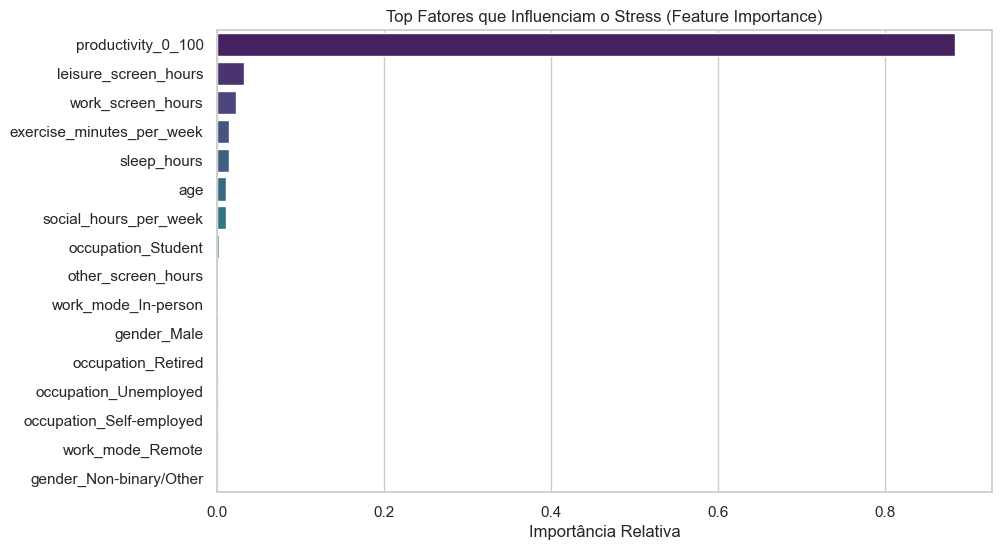

In [6]:
importances = best_rf_s.feature_importances_
indices = np.argsort(importances)[::-1]
names = [X_df.columns[i] for i in indices]

plt.figure(figsize=(10, 6))
sns.barplot(x=importances[indices], y=names, hue=names, palette='viridis', legend=False)
plt.title("Top Fatores que Influenciam o Stress (Feature Importance)")
plt.xlabel("Importância Relativa")
plt.show()

### 2.4 Previsão de SONO (Target: `sleep_quality_1_5`)

In [7]:
X_train_sl, X_test_sl, y_train_sl, y_test_sl = train_test_split(X_df, y_sleep, test_size=0.2, random_state=42)

# A. Regressão Linear
res_lr_sleep = avaliar_modelo(LinearRegression(), X_train_sl, X_test_sl, y_train_sl, y_test_sl, "Linear Regression (Sono)")

# B. Random Forest (Reutilizando grid simples)
print("\n⚙️ A otimizar Random Forest para Sono...")
grid_rf_sl = GridSearchCV(RandomForestRegressor(random_state=42), param_grid, cv=3, scoring='r2', n_jobs=-1)
grid_rf_sl.fit(X_train_sl, y_train_sl)

best_rf_sl = grid_rf_sl.best_estimator_
res_rf_sleep = avaliar_modelo(best_rf_sl, X_train_sl, X_test_sl, y_train_sl, y_test_sl, "Random Forest Tuned (Sono)")

🔹 Linear Regression (Sono)
   R²: 0.5926 | RMSE: 0.4388 | MAE: 0.3531

⚙️ A otimizar Random Forest para Sono...
🔹 Random Forest Tuned (Sono)
   R²: 0.5793 | RMSE: 0.4458 | MAE: 0.3287


In [8]:
# Seleção Automática dos Vencedores da Regressão
final_model_stress = res_rf_stress['model'] if res_rf_stress['r2'] > res_lr_stress['r2'] else res_lr_stress['model']
final_model_sleep = res_rf_sleep['model'] if res_rf_sleep['r2'] > res_lr_sleep['r2'] else res_lr_sleep['model']

print("\n🏆 VENCEDORES SELECIONADOS:")
print(f"Stress: {type(final_model_stress).__name__}")
print(f"Sono:   {type(final_model_sleep).__name__}")


🏆 VENCEDORES SELECIONADOS:
Stress: RandomForestRegressor
Sono:   LinearRegression


## 3. Clustering (Unsupervised Learning)

### 3.1 Definição do K Ideal (Silhouette Score + Cotovelo)
Análise para encontrar o número natural de grupos nos dados.

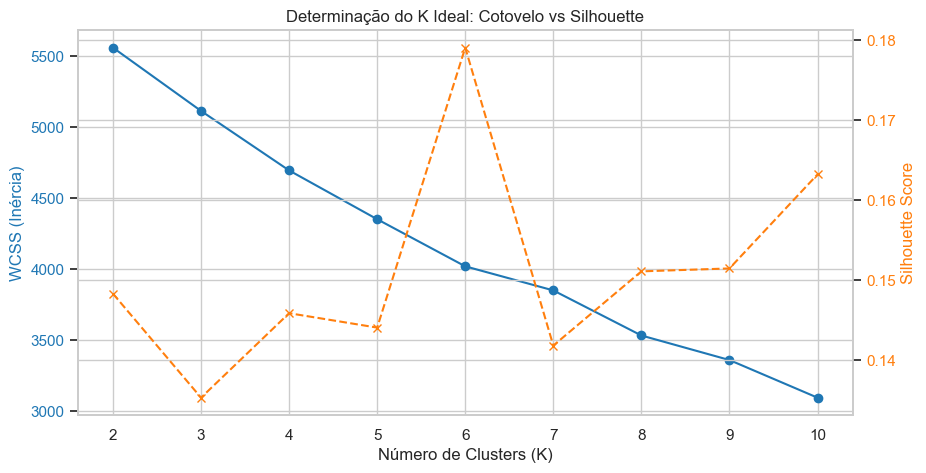

In [9]:
wcss = []
sil_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_df)
    wcss.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X_df, kmeans.labels_))

fig, ax1 = plt.subplots(figsize=(10, 5))

# WCSS (Eixo esquerdo)
ax1.set_xlabel('Número de Clusters (K)')
ax1.set_ylabel('WCSS (Inércia)', color='tab:blue')
ax1.plot(K_range, wcss, marker='o', color='tab:blue', label='WCSS')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Silhouette (Eixo direito)
ax2 = ax1.twinx()
ax2.set_ylabel('Silhouette Score', color='tab:orange')
ax2.plot(K_range, sil_scores, marker='x', linestyle='--', color='tab:orange', label='Silhouette')
ax2.tick_params(axis='y', labelcolor='tab:orange')

plt.title('Determinação do K Ideal: Cotovelo vs Silhouette')
plt.show()

### 3.2 Visualização dos Clusters (PCA)
Forçamos K=3 para análise de negócio (Perfis de Utilizador), mas validamos a separação com PCA 2D.

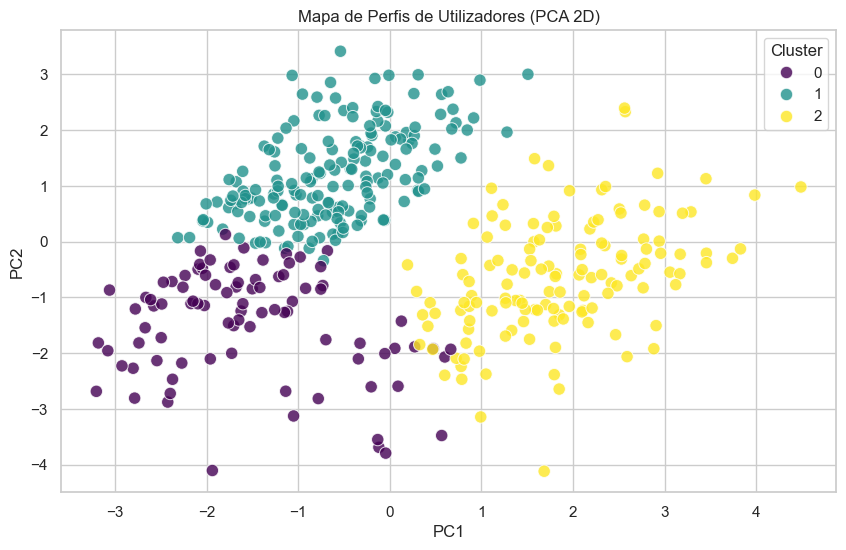

In [16]:
kmeans_final = KMeans(n_clusters=3, init='k-means++', random_state=42, n_init=10)
clusters = kmeans_final.fit_predict(X_df)
df_prep['Cluster'] = clusters

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_df)
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['Cluster'] = clusters

plt.figure(figsize=(10, 6))
sns.scatterplot(x='PC1', y='PC2', hue='Cluster', data=pca_df, palette='viridis', s=80, alpha=0.8)
plt.title('Mapa de Perfis de Utilizadores (PCA 2D)')
plt.show()

## 4. Classificação (Decision Tree)

Transformação do problema num alerta de risco: **Baixo**, **Médio** ou **Alto** Stress.

**Configurações Cruciais Usadas:**
- `stratify`: Garante que as poucas amostras de "Baixo Stress" aparecem no teste.
- `class_weight='balanced'`: Força o modelo a aprender as classes minoritárias.

In [11]:
# 1. Categorizar Target
def categorizar(v): return 'Baixo' if v<=3 else 'Médio' if v<=7 else 'Alto'
y_class = df_encoded['stress_level_0_10'].apply(categorizar)

# 2. Split Estratificado
X_tr_c, X_te_c, y_tr_c, y_te_c = train_test_split(X_df, y_class, test_size=0.2, random_state=42, stratify=y_class)

# 3. Treino Balanceado
dt_model = DecisionTreeClassifier(max_depth=4, random_state=42, class_weight='balanced')
dt_model.fit(X_tr_c, y_tr_c)

# 4. Avaliação
y_pred_c = dt_model.predict(X_te_c)

print("Relatório de Classificação:")
print(classification_report(y_te_c, y_pred_c))

Relatório de Classificação:
              precision    recall  f1-score   support

        Alto       0.95      0.90      0.92        58
       Baixo       0.67      1.00      0.80         2
       Médio       0.73      0.80      0.76        20

    accuracy                           0.88        80
   macro avg       0.78      0.90      0.83        80
weighted avg       0.88      0.88      0.88        80



### 4.2 Matriz de Confusão
Verificar visualmente se os casos "Baixo" foram detetados.

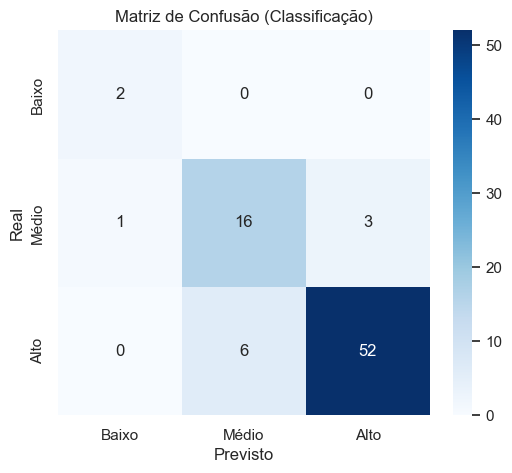

In [12]:
labels = ['Baixo', 'Médio', 'Alto']
cm = confusion_matrix(y_te_c, y_pred_c, labels=labels)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title('Matriz de Confusão (Classificação)')
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.show()

### 4.3 Regras de Negócio (Árvore em Texto)
Abaixo estão as regras exatas que a árvore aprendeu, em formato legível.

In [13]:
print("REGRAS DE DECISÃO DA ÁRVORE:\n")
regras = export_text(dt_model, feature_names=list(X_df.columns))
print(regras)

REGRAS DE DECISÃO DA ÁRVORE:

|--- productivity_0_100 <= 1.68
|   |--- productivity_0_100 <= 0.38
|   |   |--- productivity_0_100 <= -0.36
|   |   |   |--- class: Alto
|   |   |--- productivity_0_100 >  -0.36
|   |   |   |--- social_hours_per_week <= -0.11
|   |   |   |   |--- class: Alto
|   |   |   |--- social_hours_per_week >  -0.11
|   |   |   |   |--- class: Alto
|   |--- productivity_0_100 >  0.38
|   |   |--- exercise_minutes_per_week <= -1.35
|   |   |   |--- class: Alto
|   |   |--- exercise_minutes_per_week >  -1.35
|   |   |   |--- productivity_0_100 <= 0.84
|   |   |   |   |--- class: Médio
|   |   |   |--- productivity_0_100 >  0.84
|   |   |   |   |--- class: Médio
|--- productivity_0_100 >  1.68
|   |--- leisure_screen_hours <= -0.44
|   |   |--- work_screen_hours <= -0.61
|   |   |   |--- sleep_hours <= 0.00
|   |   |   |   |--- class: Médio
|   |   |   |--- sleep_hours >  0.00
|   |   |   |   |--- class: Baixo
|   |   |--- work_screen_hours >  -0.61
|   |   |   |--- ag

### 4.4 Visualização Gráfica da Árvore

Para além das regras em texto, podemos visualizar a árvore graficamente para entender os nós de decisão.

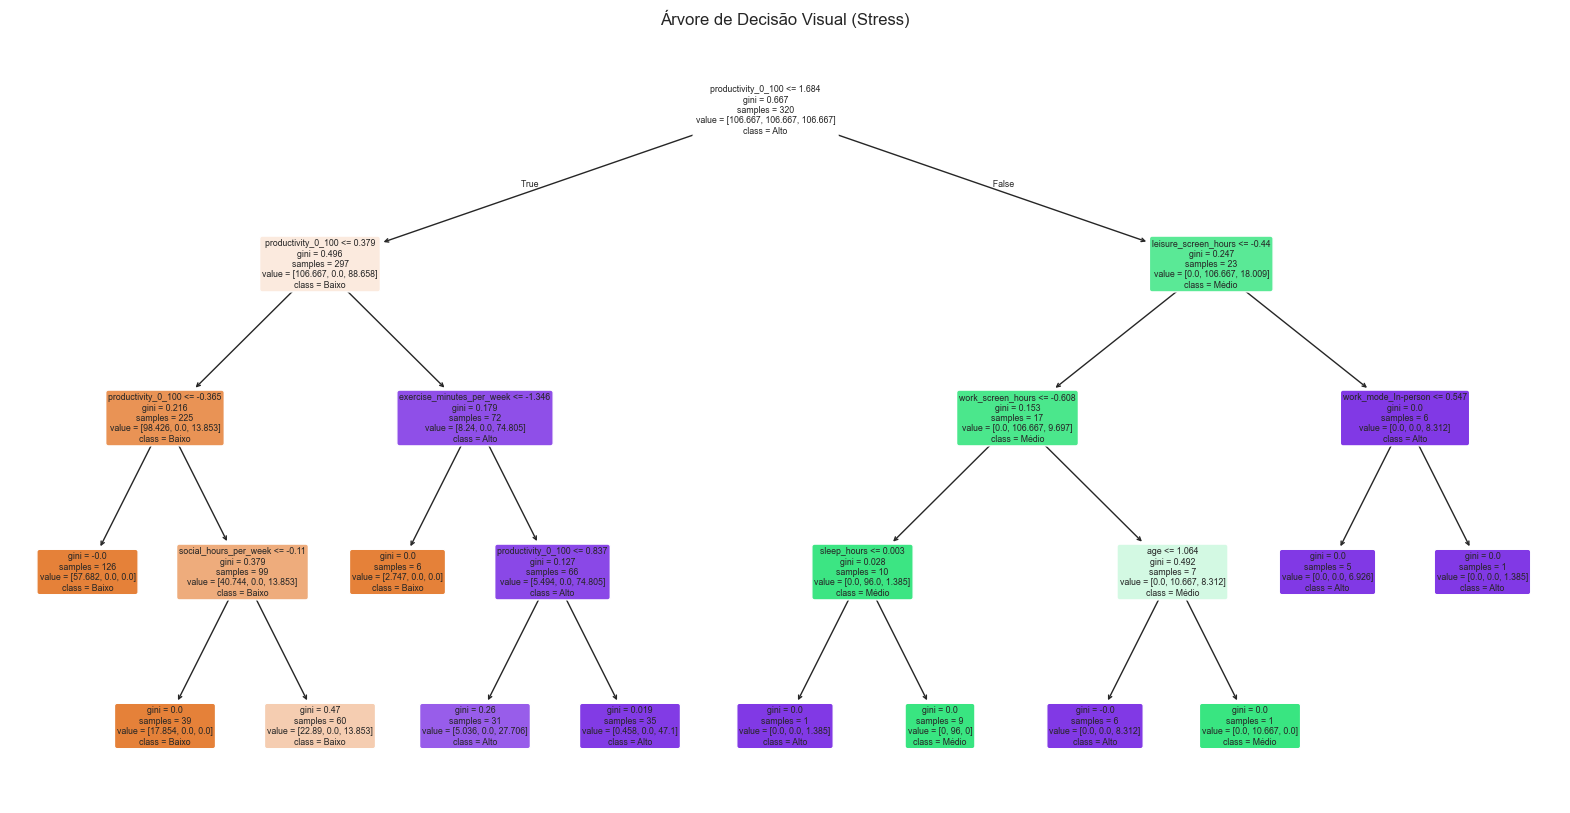

In [14]:
plt.figure(figsize=(20, 10))
plot_tree(dt_model, feature_names=list(X_df.columns), class_names=['Baixo', 'Médio', 'Alto'], filled=True, rounded=True)
plt.title("Árvore de Decisão Visual (Stress)")
plt.show()

## 5. Exportação Final (Deployment)
Salvar todos os artefactos para o Projeto 2.

In [15]:
joblib.dump(final_model_stress, 'modelo_stress.pkl')
joblib.dump(final_model_sleep, 'modelo_sono.pkl')
joblib.dump(dt_model, 'modelo_classificacao_stress.pkl')
joblib.dump(kmeans_final, 'modelo_clustering.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("Todos os modelos foram exportados com sucesso!")

Todos os modelos foram exportados com sucesso!
